# MK5: Phase-Connected CW Sampler with Prior-Snap Mode Hopping

## Problem
We sample 13 parameters for a continuous gravitational wave (CW) in PTA data:
- **8 CW parameters**: `cos_gwtheta`, `gwphi`, `cos_inc`, `log10_mc`, `log10_fgw`, `log10_h`, `phase0`, `psi`
- **5 pulsar distances**: one per pulsar, with EM-informed Gaussian priors

The **phase-connected** model ties the pulsar-term phase directly to distance,
creating a likelihood with extremely narrow, regularly-spaced modes in each
distance dimension. Mode spacing is $\Delta L = 1 / (f_{\rm gw} \cdot (\rm kpc/c) \cdot |1 - \cos\mu|)$,
typically ~0.0006 kpc — so there are hundreds of modes per prior sigma.

## Approach
A **blocked Metropolis-Hastings** sampler with four move types:

| Move | Description | Key idea |
|------|-------------|----------|
| **CW Fisher** | 8D joint proposal from Fisher information matrix | Within-mode curvature is the same at every mode peak (verified empirically) |
| **Distance within-mode** | Small 1D refinement using Fisher width | Stays within the current mode |
| **Prior-snap big jump** | Draw from EM prior, snap to nearest mode peak | Explores across modes; 45% acceptance rate |
| **CW Gibbs** | Single CW parameter update | Helps mix individual CW dimensions |

The **prior-snap** move is the key innovation: it draws a candidate distance from the
EM-informed prior $d \sim \mathcal{N}(\mu, \sigma)$ and then snaps to the nearest
likelihood mode peak via a short 1D grid search. This naturally targets the
prior-supported region and achieves ~45% acceptance (vs ~1% for uniform mode hops).

## Key finding: Fisher information is mode-invariant
The Hessian computed at any on-peak point gives essentially the same proposal
covariance (CW block mean relative difference: 2.6%, distance diagonals: <4%).
So we compute it once and reuse everywhere.

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["JAX_DISABLE_MMAP_CACHE"] = "1"
os.environ["XLA_FLAGS"] = "--xla_gpu_autotune_level=2"

import glob, time
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_enable_x64', True)
jax.clear_caches()
import jax.numpy as jnp

import discovery as ds
from enterprise_extensions import load_feathers
from discovery.deterministic import make_phase_connected_binary
from discovery import const as disco_const
from discovery.deterministic import fpcmu_fast

print('Imports OK')

/home/mattm/miniforge3/envs/discotech/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


Imports OK


In [2]:
# Load pulsars and their EM distance priors
feather_dir = "../data_products/"
Npulsars = 5

disco_psrs = [ds.Pulsar.read_feather(f) for f in sorted(glob.glob(feather_dir + "*.feather"))][:Npulsars]
for psr in disco_psrs:
    psr.toaerrs = np.full_like(psr.toas, 1e-6, dtype=np.float32)
print(f"Loaded {len(disco_psrs)} pulsars: {[p.name for p in disco_psrs]}")

psrs_ent = load_feathers.load_feathers_from_folder(feather_dir)
ent_by_name = {p.name: p for p in psrs_ent}

dist_mu = []
dist_sig = []
for psr in disco_psrs:
    ep = ent_by_name[psr.name]
    mu = float(ep.pdist[0])
    sig = float(ep.pdist[1]) if len(ep.pdist) > 1 else 0.5
    if (not np.isfinite(sig)) or sig <= 0:
        sig = 0.5
    dist_mu.append(mu)
    dist_sig.append(sig)

dist_mu = jnp.array(dist_mu, dtype=jnp.float64)
dist_sig = jnp.array(dist_sig, dtype=jnp.float64)

psr_toas_list = [np.asarray(psr.toas, dtype=np.float64) for psr in disco_psrs]
psr_pos_list = [psr.pos for psr in disco_psrs]
psr_positions = jnp.array([psr.pos for psr in disco_psrs])

sigma_toa = 1e-6
KPC_OVER_C = disco_const.kpc / disco_const.c

pnames_13 = (['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc', 'log10_fgw',
              'log10_h', 'phase0', 'psi'] +
             [psr.name + '_dist' for psr in disco_psrs])

print(f"dist_mu: {[f'{float(d):.3f}' for d in dist_mu]}")
print(f"dist_sig: {[f'{float(d):.4f}' for d in dist_sig]}")

Loaded 5 pulsars: ['B1855+09', 'B1937+21', 'B1953+29', 'J0023+0923', 'J0030+0451']
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J0030+0451.feather.
FeatherPulsar.read_feather: cannot find _pdi

FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J1101-6424.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J1101-6424.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J1103-5403.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J1103-5403.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J1125+7819.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J1125+7819.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J1125-5825.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J1125-5825.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J1125-6014.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J1125-6014.feather.
FeatherPulsar.r

dist_mu: ['1.180', '3.100', '4.640', '1.020', '0.330']
dist_sig: ['0.1200', '0.2000', '0.9300', '0.1100', '0.0036']


In [3]:
# CW injection and log-posterior definition
INJ = {
    "cos_gwtheta": 0.3, "gwphi": 2.5, "cos_inc": -0.2,
    "log10_mc": 9.0, "log10_fgw": -8.0, "log10_h": -12.0,
    "phase0": 1.0, "psi": 0.7,
}

cw_func = make_phase_connected_binary(pulsarterm=True)

@jax.jit
def compute_delta_L(cos_gwtheta, gwphi, log10_fgw):
    """Mode spacing in distance (kpc) for each pulsar."""
    gwtheta = jnp.arccos(cos_gwtheta)
    f_gw = 10.0 ** log10_fgw
    _, _, cos_mu = jax.vmap(
        lambda pos: fpcmu_fast(pos, gwtheta, gwphi)
    )(psr_positions)
    denom = jnp.abs(1.0 - cos_mu)
    denom = jnp.maximum(denom, 1e-4)
    return 1.0 / (f_gw * KPC_OVER_C * denom)

# Inject with distances offset from prior mean by 0.3 sigma
DIST_OFFSET_SIGMA = 0.3
p5_true_dists = {}
for i, psr in enumerate(disco_psrs):
    p5_true_dists[psr.name] = float(dist_mu[i]) + DIST_OFFSET_SIGMA * float(dist_sig[i])

p5_data_list = []
for i, psr in enumerate(disco_psrs):
    toas_i = np.asarray(psr.toas, dtype=np.float64)
    delay_i = cw_func(toas_i, psr.pos, p_dist=p5_true_dists[psr.name], **INJ)
    p5_data_list.append(np.array(delay_i, dtype=np.float64))

INJ_vals = [INJ[k] for k in ['cos_gwtheta','gwphi','cos_inc','log10_mc','log10_fgw','log10_h','phase0','psi']]
p5_dist_vals = [p5_true_dists[psr.name] for psr in disco_psrs]
p5_truth = np.array(INJ_vals + p5_dist_vals)

sd_arr = np.array([float(dist_sig[i]) for i in range(Npulsars)])
mu_arr = np.array([float(dist_mu[i]) for i in range(Npulsars)])

# Log-posterior
sd_jnp = jnp.array(sd_arr, dtype=jnp.float64)
data_jnp = [jnp.array(d) for d in p5_data_list]

@jax.jit
def logp(x):
    p_dists = x[8:13]
    in_bounds = (
        (x[0] >= -1) & (x[0] <= 1) &
        (x[1] >= 0) & (x[1] <= 2*jnp.pi) &
        (x[2] >= -1) & (x[2] <= 1) &
        (x[3] >= 7) & (x[3] <= 10) &
        (x[4] >= -9) & (x[4] <= -7) &
        (x[5] >= -18) & (x[5] <= -11) &
        (x[6] >= 0) & (x[6] <= 2*jnp.pi) &
        (x[7] >= 0) & (x[7] <= jnp.pi) &
        jnp.all(p_dists > 1e-6)
    )
    ll = 0.0
    for p_idx in range(5):
        model = cw_func(
            psr_toas_list[p_idx], psr_pos_list[p_idx],
            cos_gwtheta=x[0], gwphi=x[1], cos_inc=x[2],
            log10_mc=x[3], log10_fgw=x[4], log10_h=x[5],
            phase0=x[6], psi=x[7], p_dist=p_dists[p_idx], p_phase=None
        )
        resid = data_jnp[p_idx] - model
        ll -= 0.5 * jnp.sum(resid**2) / sigma_toa**2
    log_prior = -0.5 * jnp.sum(jnp.square((p_dists - dist_mu) / sd_jnp))
    return jnp.where(in_bounds, ll + log_prior, -1e30)

# Mode spacing at truth
dL_truth = np.array(compute_delta_L(INJ['cos_gwtheta'], INJ['gwphi'], INJ['log10_fgw']))

lp_truth = float(logp(jnp.array(p5_truth)))
print(f"logp(truth) = {lp_truth:.2f}")
for i, psr in enumerate(disco_psrs):
    print(f"  {psr.name}: d_true={p5_dist_vals[i]:.4f}, dL={dL_truth[i]:.6f}, "
          f"modes/sig={float(dist_sig[i])/dL_truth[i]:.0f}")

logp(truth) = -0.23
  B1855+09: d_true=1.2160, dL=0.000580, modes/sig=207
  B1937+21: d_true=3.1600, dL=0.000583, modes/sig=343
  B1953+29: d_true=4.9190, dL=0.000603, modes/sig=1542
  J0023+0923: d_true=1.0530, dL=0.000591, modes/sig=186
  J0030+0451: d_true=0.3307, dL=0.000587, modes/sig=6


In [4]:
# Compute Fisher information at any on-peak point.
#
# The Hessian is MODE-INVARIANT (verified in MK4: CW block mean rel diff
# = 2.6%, distance diagonals < 4%). So we compute it at whatever starting
# point we have — doesn't need to be the truth.

# JIT-compiled gradient for Newton snapping
grad_logp = jax.jit(jax.grad(logp))

def compute_fisher(x_peak, logp_fn):
    """Compute CW proposal components and distance Fisher widths at a mode peak.
    
    Returns dict with:
      - L_cw: 8x8 Cholesky for joint 8D proposal
      - eig_vecs: (8,8) eigenvectors of CW covariance (columns)
      - eig_sigs: (8,) per-eigenmode proposal widths (1D optimal scaling)
      - dist_fisher_sig: (Npsr,) per-pulsar within-mode widths
      - cw_gibbs_sig: (8,) per-param Gibbs step sizes
      - H_dist_diag: (Npsr,) Hessian diagonal for distance params (for Newton snap)
    """
    print("  Computing Hessian...")
    t0 = time.time()
    H_full = np.array(jax.hessian(logp_fn)(jnp.array(x_peak)))
    dt = time.time() - t0
    print(f"  Hessian computed in {dt:.1f}s")
    
    Npsr = len(x_peak) - 8
    
    # 8x8 CW sub-block
    H_cw = H_full[:8, :8]
    neg_H_cw = -H_cw
    eig_cw, evec_cw = np.linalg.eigh(neg_H_cw)
    eig_cw_c = np.maximum(eig_cw, 1e-12 * eig_cw.max())
    cov_cw = evec_cw @ np.diag(1.0 / eig_cw_c) @ evec_cw.T
    cov_cw = 0.5 * (cov_cw + cov_cw.T)
    
    # Joint 8D Cholesky
    scale_8d = 2.38**2 / 8
    L_cw = np.linalg.cholesky(scale_8d * cov_cw)
    
    # Eigenmode proposals
    eig_vals_cov, eig_vecs_cov = np.linalg.eigh(cov_cw)
    scale_1d = 2.38
    eig_sigs = scale_1d * np.sqrt(np.maximum(eig_vals_cov, 1e-30))
    
    print(f"\n  CW Fisher eigenvalues (precision): {eig_cw}")
    print(f"  Eigenmode proposal widths: {eig_sigs}")
    print(f"  Eigenvalue range: {eig_cw.max()/eig_cw.min():.1e}")
    
    # Per-pulsar distance Fisher widths + Hessian diagonals
    dist_fisher_sig = np.zeros(Npsr)
    H_dist_diag = np.zeros(Npsr)
    dL_at_peak = np.array(compute_delta_L(x_peak[0], x_peak[1], x_peak[4]))
    for j in range(Npsr):
        H_dist_diag[j] = H_full[8+j, 8+j]  # negative (concave)
        neg_hess_jj = -H_dist_diag[j]
        if neg_hess_jj > 0:
            dist_fisher_sig[j] = 1.0 / np.sqrt(neg_hess_jj)
        else:
            dist_fisher_sig[j] = dL_at_peak[j] * 0.3
    
    cw_gibbs_sig = np.diag(L_cw).copy()
    
    for j in range(Npsr):
        print(f"  Pulsar {j}: Fisher sig_d={dist_fisher_sig[j]:.6f}, "
              f"dL={dL_at_peak[j]:.6f}, ratio={dist_fisher_sig[j]/dL_at_peak[j]:.3f}")
    
    return dict(L_cw=L_cw, eig_vecs=eig_vecs_cov, eig_sigs=eig_sigs,
                dist_fisher_sig=dist_fisher_sig, cw_gibbs_sig=cw_gibbs_sig,
                H_dist_diag=H_dist_diag)

# Compute at truth for Test 1
print("Fisher at truth:")
fisher = compute_fisher(p5_truth, logp)
L_cw = fisher['L_cw']
dist_fisher_sig = fisher['dist_fisher_sig']
cw_gibbs_sig = fisher['cw_gibbs_sig']
eig_vecs = fisher['eig_vecs']
eig_sigs = fisher['eig_sigs']
print("Done")

Fisher at truth:
  Computing Hessian...


  Hessian computed in 13.8s

  CW Fisher eigenvalues (precision): [6.90991437e+02 2.42456760e+03 1.61973609e+04 6.38987584e+04
 3.42348882e+06 2.30493613e+10 3.22600784e+10 1.49897025e+13]
  Eigenmode proposal widths: [6.14724474e-07 1.32508656e-05 1.56764424e-05 1.28630068e-03
 9.41522596e-03 1.87005693e-02 4.83347869e-02 9.05400280e-02]
  Eigenvalue range: 2.2e+10
  Pulsar 0: Fisher sig_d=0.000003, dL=0.000580, ratio=0.006
  Pulsar 1: Fisher sig_d=0.000002, dL=0.000583, ratio=0.004
  Pulsar 2: Fisher sig_d=0.000004, dL=0.000603, ratio=0.007
  Pulsar 3: Fisher sig_d=0.000005, dL=0.000591, ratio=0.008
  Pulsar 4: Fisher sig_d=0.000003, dL=0.000587, ratio=0.005
Done


In [5]:
# ============================================================
# Blocked MCMC sampler with:
#   - Eigenmode CW proposals (1D along Fisher eigenvectors)
#     with per-eigenmode Robbins-Monro adaptive scaling
#   - Hessian recomputation at mid-burn-in for better eigenvectors
#   - Prior-snap big jumps for distances
#   - Coherent frequency-distance proposal using Newton snap
# ============================================================

def snap_to_peak(x13, pulsar_idx, dL_j, n_pts=50):
    """Find the nearest mode peak for one pulsar via fine 1D scan."""
    d_center = x13[8 + pulsar_idx]
    d_lo = max(d_center - 0.6 * dL_j, 1e-6)
    d_hi = d_center + 0.6 * dL_j
    d_candidates = np.linspace(d_lo, d_hi, n_pts)
    x_batch = np.tile(x13, (len(d_candidates), 1))
    x_batch[:, 8 + pulsar_idx] = d_candidates
    lps_scan = np.array(jax.vmap(logp)(jnp.array(x_batch)))
    return float(d_candidates[np.argmax(lps_scan)])


def ess_1d(x, max_lag=500):
    """Effective sample size from autocorrelation."""
    n = len(x)
    x = x - x.mean()
    var = np.var(x)
    if var < 1e-30:
        return 1.0
    acf = np.correlate(x, x, mode='full')[n-1:n-1+max_lag+1] / (n * var)
    cutoff = np.argmax(acf < 0.05)
    if cutoff == 0:
        cutoff = max_lag
    tau = 1.0 + 2.0 * np.sum(acf[1:cutoff])
    return n / max(tau, 1.0)


def run_sampler(logp_fn, x0, rng, fisher_dict, dL_arr, mu_arr, sig_arr,
                n_burn=3000, n_prod=10000, report_every=2000,
                # Move probabilities
                p_cw_eigen=0.35, p_dist_within=0.10,
                p_big_jump=0.30, p_freq_dist=0.10,
                p_cw_joint=0.15,
                # Coherent freq-dist proposal width (tuned for ~44% AR)
                freq_dist_sigma=3e-4,
                # Number of Newton iterations for distance correction
                n_newton=3,
                # Per-eigenmode adaptive scaling (Robbins-Monro)
                adapt_target=0.44, adapt_rate=0.8, adapt_t0=50,
                # Hessian recomputation: at what fraction of burn-in
                recompute_hessian_at=0.4):
    """Blocked MH sampler with eigenmode CW, prior-snap big jumps,
    and coherent frequency-distance proposals with Newton snapping.
    
    Hessian recomputation:
      At recompute_hessian_at * n_burn steps into burn-in, recompute
      the Hessian at the current position. This gives eigenvectors
      aligned with the posterior after big jumps have moved distances
      to better modes. Adaptive scaling then fine-tunes from there.
    
    Per-eigenmode adaptive scaling:
      Each eigenmode i has its own scale factor s_i (initialized to 1).
      After each eigenmode proposal, we update:
        log(s_i) += gamma_t * (accepted - target_ar)
      Adaptation runs during burn-in only to preserve detailed balance.
    """
    D = len(x0)
    Npsr = D - 8
    x = x0.copy().astype(np.float64)
    lp = float(logp_fn(jnp.array(x)))
    
    # Unpack Fisher components
    L_cw = fisher_dict['L_cw'].copy()
    eig_vecs = fisher_dict['eig_vecs'].copy()
    eig_sigs = fisher_dict['eig_sigs'].copy()
    dist_fisher_sig = fisher_dict['dist_fisher_sig'].copy()
    H_dist_diag = fisher_dict['H_dist_diag'].copy()
    
    # Per-eigenmode adaptive scale factors (log space)
    log_scale = np.zeros(8)
    eig_adapt_count = np.zeros(8)
    
    chain = np.zeros((n_prod, D))
    lps = np.zeros(n_prod)
    
    acc = {'cw_eigen': 0, 'dist_within': 0, 'big_jump': 0,
           'freq_dist': 0, 'cw_joint': 0}
    tot = {k: 0 for k in acc}
    
    eig_acc = np.zeros(8)
    eig_tot = np.zeros(8)
    
    t1 = p_cw_eigen
    t2 = t1 + p_dist_within
    t3 = t2 + p_big_jump
    t4 = t3 + p_freq_dist
    
    total_steps = n_burn + n_prod
    recompute_step = int(recompute_hessian_at * n_burn)  # absolute step to recompute
    hessian_recomputed = False
    t0 = time.time()
    
    for step in range(-n_burn, n_prod):
        abs_step = step + n_burn
        
        # --- Hessian recomputation at mid-burn-in ---
        if not hessian_recomputed and abs_step == recompute_step:
            print(f"  [Recomputing Hessian at burn-in step {abs_step}]")
            # Snap current position to peak first (ensure on-peak)
            x_snap = x.copy()
            for j in range(Npsr):
                dL_j = float(np.array(compute_delta_L(x[0], x[1], x[4]))[j])
                x_snap[8+j] = snap_to_peak(x_snap, j, dL_j)
            
            new_fisher = compute_fisher(x_snap, logp_fn)
            L_cw = new_fisher['L_cw']
            eig_vecs = new_fisher['eig_vecs']
            eig_sigs = new_fisher['eig_sigs']
            dist_fisher_sig = new_fisher['dist_fisher_sig']
            H_dist_diag = new_fisher['H_dist_diag']
            
            # Reset adaptive scales since eigenvectors changed
            log_scale = np.zeros(8)
            eig_adapt_count = np.zeros(8)
            hessian_recomputed = True
            print(f"  [Hessian recomputed, adaptive scales reset]")
        
        r = rng.random()
        
        if r < t1:
            # --- CW eigenmode: 1D proposal along random eigenvector ---
            mode_idx = rng.integers(8)
            z = rng.standard_normal()
            scaled_sig = eig_sigs[mode_idx] * np.exp(log_scale[mode_idx])
            x_prop = x.copy()
            x_prop[:8] += z * scaled_sig * eig_vecs[:, mode_idx]
            lp_prop = float(logp_fn(jnp.array(x_prop)))
            accepted = np.log(rng.random() + 1e-300) < lp_prop - lp
            if accepted:
                x = x_prop; lp = lp_prop
                acc['cw_eigen'] += 1
                eig_acc[mode_idx] += 1
            tot['cw_eigen'] += 1
            eig_tot[mode_idx] += 1
            
            # Robbins-Monro adaptation (burn-in only)
            if step < 0:
                eig_adapt_count[mode_idx] += 1
                gamma = adapt_rate / (eig_adapt_count[mode_idx] + adapt_t0)
                log_scale[mode_idx] += gamma * (float(accepted) - adapt_target)
                log_scale[mode_idx] = np.clip(log_scale[mode_idx], -3.0, 3.0)
            
        elif r < t2:
            # --- Within-mode distance refinement ---
            pi = rng.integers(Npsr)
            x_prop = x.copy()
            x_prop[8+pi] += dist_fisher_sig[pi] * rng.standard_normal()
            if x_prop[8+pi] > 1e-6:
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['dist_within'] += 1
            tot['dist_within'] += 1
            
        elif r < t3:
            # --- Prior-snap big jump ---
            pi = rng.integers(Npsr)
            d_prop = rng.normal(mu_arr[pi], sig_arr[pi])
            if d_prop > float(dL_arr[pi]):
                x_snap = x.copy()
                x_snap[8+pi] = d_prop
                d_snapped = snap_to_peak(x_snap, pi, float(dL_arr[pi]))
                x_prop = x.copy()
                x_prop[8+pi] = d_snapped
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['big_jump'] += 1
            tot['big_jump'] += 1
            
        elif r < t4:
            # --- Coherent frequency-distance proposal (Newton snap) ---
            delta = rng.standard_normal() * freq_dist_sigma
            x_prop = x.copy()
            x_prop[4] += delta
            
            if -9 <= x_prop[4] <= -7:
                scale_factor = 10.0 ** (-delta)
                for j in range(Npsr):
                    x_prop[8 + j] *= scale_factor
                
                for _newton in range(n_newton):
                    g = np.array(grad_logp(jnp.array(x_prop)))
                    for j in range(Npsr):
                        if H_dist_diag[j] < -1e-6:
                            newton_step = -g[8 + j] / H_dist_diag[j]
                            x_prop[8 + j] += newton_step
                            x_prop[8 + j] = max(x_prop[8 + j], 1e-6)
                
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['freq_dist'] += 1
            tot['freq_dist'] += 1
            
        else:
            # --- CW joint 8D Fisher ---
            z = rng.standard_normal(8)
            x_prop = x.copy()
            x_prop[:8] += L_cw @ z
            lp_prop = float(logp_fn(jnp.array(x_prop)))
            if np.log(rng.random() + 1e-300) < lp_prop - lp:
                x = x_prop; lp = lp_prop; acc['cw_joint'] += 1
            tot['cw_joint'] += 1
        
        if step >= 0:
            chain[step] = x
            lps[step] = lp
        
        # Update mode spacing periodically
        if abs_step > 0 and abs_step % 2000 == 0:
            dL_arr = np.array(compute_delta_L(x[0], x[1], x[4]))
        
        # Progress report
        if abs_step > 0 and abs_step % report_every == 0:
            elapsed = time.time() - t0
            phase = 'burn' if step < 0 else 'prod'
            rate = abs_step / elapsed
            eta = (total_steps - abs_step) / rate
            ar_bj = acc['big_jump'] / max(tot['big_jump'], 1)
            ar_eig = acc['cw_eigen'] / max(tot['cw_eigen'], 1)
            ar_fd = acc['freq_dist'] / max(tot['freq_dist'], 1)
            print(f"  [{phase} {abs_step}/{total_steps}] lp={lp:.2f} "
                  f"EIG={ar_eig:.3f} BJ={ar_bj:.3f} FD={ar_fd:.3f} "
                  f"[{rate:.0f} it/s, ETA {eta:.0f}s]")
    
    dt_total = time.time() - t0
    ar_dict = {k: acc[k]/max(tot[k],1) for k in acc}
    print(f"\nDone in {dt_total:.1f}s ({total_steps/dt_total:.0f} it/s)")
    for k in acc:
        print(f"  {k:15s}: {acc[k]:6d}/{tot[k]:6d} = {ar_dict[k]:.4f}")
    
    # Per-eigenmode AR and adapted scales
    print(f"\n  Per-eigenmode AR (adapted scale factors):")
    for i in range(8):
        ar_i = eig_acc[i] / max(eig_tot[i], 1)
        s_i = np.exp(log_scale[i])
        print(f"    mode {i} (sig={eig_sigs[i]:.2e}, scale={s_i:.3f}): "
              f"{int(eig_acc[i])}/{int(eig_tot[i])} = {ar_i:.4f}")
    
    return chain, lps, ar_dict

print("Sampler defined (eigenmode + Hessian recomp + adaptive + freq-dist Newton)")

Sampler defined (eigenmode + Hessian recomp + adaptive + freq-dist Newton)


In [6]:
def run_diagnostics(chain, lps, ar, truth, dL, title='', show_start=None):
    """Print diagnostics and plot traces / posteriors."""
    Npsr = chain.shape[1] - 8
    cw_keys = ['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc',
               'log10_fgw', 'log10_h', 'phase0', 'psi']
    
    # Coverage
    cov = sum(1 for k in range(13)
              if np.percentile(chain[:,k], 5) <= truth[k] <= np.percentile(chain[:,k], 95))
    print(f"Coverage: {cov}/13")
    
    # ESS
    ess_vals = {pnames_13[k]: ess_1d(chain[:,k]) for k in range(13)}
    print(f"ESS range: [{min(ess_vals.values()):.0f}, {max(ess_vals.values()):.0f}]")
    for k, v in ess_vals.items():
        print(f"  {k:20s}: ESS={v:.0f}")
    
    # Distance errors
    print(f"\nDistance errors:")
    for j in range(Npsr):
        med = np.median(chain[:, 8+j])
        err_dL = abs(med - truth[8+j]) / dL[j]
        print(f"  {disco_psrs[j].name:13s}: median={med:.6f}, truth={truth[8+j]:.6f}, "
              f"err={err_dL:.1f} dL")
    
    # Acceptance rates
    print(f"\nAcceptance rates:")
    for k, v in ar.items():
        print(f"  {k:15s}: {v:.4f}")
    
    # --- Plots ---
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.suptitle(f'{title} (cov={cov}/13)', fontsize=14)
    
    # logp trace
    ax = axes[0, 0]
    ax.plot(lps, color='#1a3a5c', lw=0.4, alpha=0.8)
    ax.axhline(float(logp(jnp.array(truth))), color='r', ls='--', lw=1, label='truth')
    ax.set_xlabel('step'); ax.set_ylabel('logp')
    ax.set_title('Log-posterior trace'); ax.legend(fontsize=8)
    
    # CW param traces
    for i, idx in enumerate([0, 1, 4, 5]):
        ax = axes[0, 1] if i == 0 else axes[0, 2] if i == 1 else axes[1, 0] if i == 2 else axes[1, 1]
        ax.plot(chain[:, idx], color='#1a3a5c', lw=0.4, alpha=0.8)
        ax.axhline(truth[idx], color='r', ls='--', lw=1)
        ax.set_title(cw_keys[idx]); ax.set_xlabel('step')
    
    # Distance traces
    ax = axes[1, 2]
    colours = ['#1a3a5c', '#8b2500', '#2d5a27']
    for j in range(min(3, Npsr)):
        ax.plot(chain[:, 8+j], alpha=0.7, lw=0.4, color=colours[j],
                label=disco_psrs[j].name[:8])
        ax.axhline(truth[8+j], color=colours[j], ls='--', lw=0.8)
        if show_start is not None:
            ax.axhline(show_start[8+j], color=colours[j], ls=':', lw=0.8, alpha=0.5)
    ax.set_xlabel('step'); ax.set_ylabel('dist (kpc)')
    ax.set_title('Distance traces (first 3)'); ax.legend(fontsize=7)
    
    # Distance posteriors vs priors
    for j in range(min(3, Npsr)):
        ax = axes[2, j]
        ax.hist(chain[:, 8+j], bins=80, density=True, alpha=0.7, color='#2b5797')
        ax.axvline(truth[8+j], color='r', ls='--', lw=1.5, label='truth')
        ax.axvline(float(dist_mu[j]), color='green', ls=':', lw=1.5, label='prior mean')
        if show_start is not None:
            ax.axvline(show_start[8+j], color='orange', ls=':', lw=1.5, label='start')
        ax.set_title(f'{disco_psrs[j].name[:8]} dist'); ax.legend(fontsize=7)
    
    plt.tight_layout(); plt.show()
    return cov, ess_vals

print("Diagnostics function defined")

Diagnostics function defined


## Test 1: Start from truth

Baseline test to verify the sampler works when starting at the correct mode.
Expected: high coverage, CW Fisher AR ~0.2, big-jump AR ~0.45.

Test 1: Start from truth (eigenmode CW proposals)
  logp(truth) = -0.23


  [burn 3000/23000] lp=-7.18 EIG=0.371 BJ=0.380 FD=0.419 [339 it/s, ETA 59s]
  [Recomputing Hessian at burn-in step 3200]
  Computing Hessian...


  Hessian computed in 0.4s

  CW Fisher eigenvalues (precision): [5.04946138e+02 3.34905199e+03 1.47427664e+04 6.09940804e+04
 3.07989144e+07 1.92266507e+10 2.57372152e+10 1.45424181e+13]
  Eigenmode proposal widths: [6.24106446e-07 1.48352948e-05 1.71642621e-05 4.28853790e-04
 9.63680593e-03 1.96014168e-02 4.11259566e-02 1.05914258e-01]
  Eigenvalue range: 2.9e+10
  Pulsar 0: Fisher sig_d=0.000003, dL=0.000579, ratio=0.006
  Pulsar 1: Fisher sig_d=0.000002, dL=0.000582, ratio=0.004
  Pulsar 2: Fisher sig_d=0.000004, dL=0.000602, ratio=0.007
  Pulsar 3: Fisher sig_d=0.000005, dL=0.000590, ratio=0.008
  Pulsar 4: Fisher sig_d=0.000003, dL=0.000587, ratio=0.005
  [Hessian recomputed, adaptive scales reset]


  [burn 6000/23000] lp=-3.16 EIG=0.363 BJ=0.410 FD=0.414 [492 it/s, ETA 35s]


  [prod 9000/23000] lp=-2.23 EIG=0.361 BJ=0.415 FD=0.421 [600 it/s, ETA 23s]


...

  [prod 15000/23000] lp=-5.60 EIG=0.367 BJ=0.411 FD=0.413 [743 it/s, ETA 11s]


  [prod 18000/23000] lp=-2.39 EIG=0.368 BJ=0.410 FD=0.415 [792 it/s, ETA 6s]


  [prod 21000/23000] lp=-5.56 EIG=0.367 BJ=0.413 FD=0.419 [829 it/s, ETA 2s]



Done in 27.1s (850 it/s)
  cw_eigen       :   4205/ 11463 = 0.3668
  dist_within    :    829/  1156 = 0.7171
  big_jump       :   1922/  4659 = 0.4125
  freq_dist      :    958/  2318 = 0.4133
  cw_joint       :    444/  3404 = 0.1304

  Per-eigenmode AR (adapted scale factors):
    mode 0 (sig=6.24e-07, scale=0.987): 636/1424 = 0.4466
    mode 1 (sig=1.48e-05, scale=0.973): 588/1444 = 0.4072
    mode 2 (sig=1.72e-05, scale=0.983): 527/1362 = 0.3869
    mode 3 (sig=4.29e-04, scale=0.744): 405/1477 = 0.2742
    mode 4 (sig=9.64e-03, scale=0.967): 596/1433 = 0.4159
    mode 5 (sig=1.96e-02, scale=0.968): 624/1464 = 0.4262
    mode 6 (sig=4.11e-02, scale=0.819): 487/1414 = 0.3444
    mode 7 (sig=1.06e-01, scale=0.712): 342/1445 = 0.2367
Coverage: 10/13


ESS range: [17, 259]
  cos_gwtheta         : ESS=17
  gwphi               : ESS=19
  cos_inc             : ESS=22
  log10_mc            : ESS=17
  log10_fgw           : ESS=19
  log10_h             : ESS=25
  phase0              : ESS=21
  psi                 : ESS=75
  B1855+09_dist       : ESS=60
  B1937+21_dist       : ESS=54
  B1953+29_dist       : ESS=90
  J0023+0923_dist     : ESS=259
  J0030+0451_dist     : ESS=232

Distance errors:
  B1855+09     : median=1.186643, truth=1.216000, err=50.6 dL
  B1937+21     : median=3.103220, truth=3.160000, err=97.5 dL
  B1953+29     : median=4.817122, truth=4.919000, err=169.0 dL
  J0023+0923   : median=1.021949, truth=1.053000, err=52.5 dL
  J0030+0451   : median=0.329285, truth=0.330680, err=2.4 dL

Acceptance rates:
  cw_eigen       : 0.3668
  dist_within    : 0.7171
  big_jump       : 0.4125
  freq_dist      : 0.4133
  cw_joint       : 0.1304


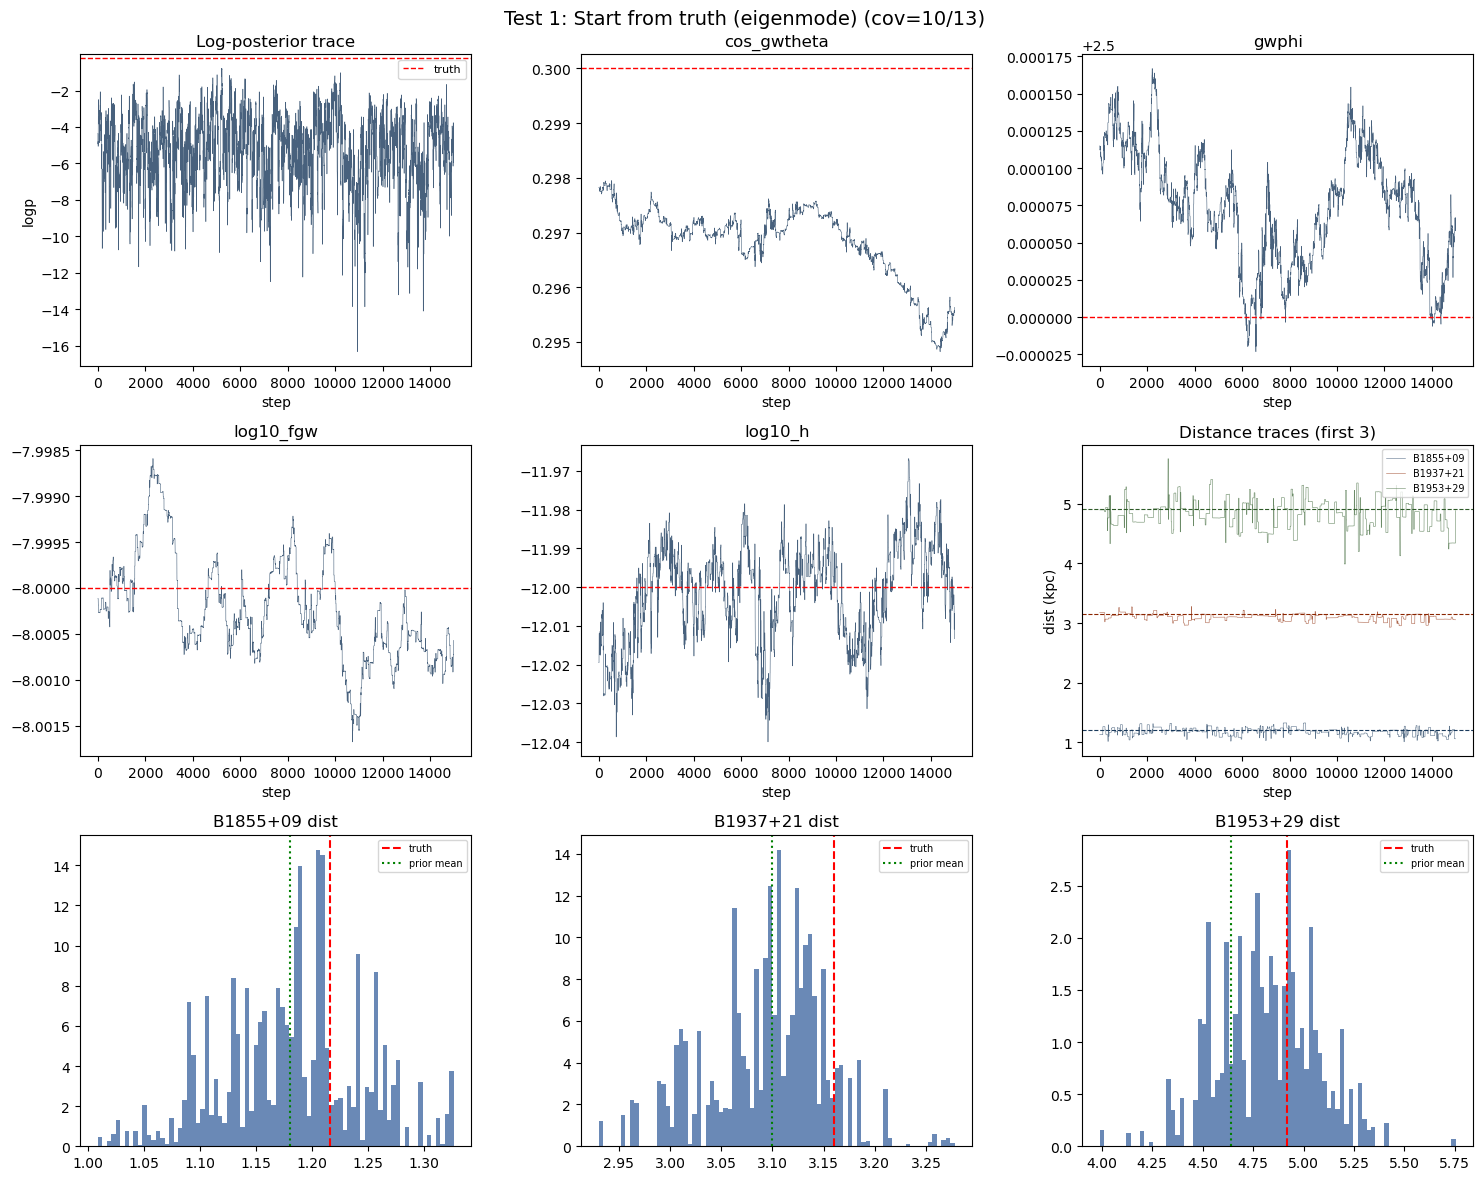

In [7]:
print("Test 1: Start from truth (eigenmode CW proposals)")
print(f"  logp(truth) = {lp_truth:.2f}")

dL_start = np.array(compute_delta_L(p5_truth[0], p5_truth[1], p5_truth[4]))

chain1, lps1, ar1 = run_sampler(
    logp, p5_truth.copy(), np.random.default_rng(42),
    fisher_dict=fisher, dL_arr=dL_start, mu_arr=mu_arr, sig_arr=sd_arr,
    n_burn=8000, n_prod=15000, report_every=3000,
    p_cw_eigen=0.50, p_dist_within=0.05,
    p_big_jump=0.20, p_freq_dist=0.10,
    p_cw_joint=0.15)

cov1, ess1 = run_diagnostics(chain1, lps1, ar1, p5_truth, dL_start,
                              title='Test 1: Start from truth (eigenmode)')

## Test 2: Start from a wrong mode (shifted distances)

The real test: can the prior-snap big jumps find the correct mode when
starting hundreds of modes away? We shift each distance by a random number
of modes (staying within 2-sigma of the EM prior), then snap to the nearest
peak so we start on-mode but at the wrong mode.

Shifting distances to wrong modes (within 2-sigma of prior)...
Snapping to nearest mode peaks...



Shifted starting point:
  logp = -12.05  (truth = -0.23, delta = -11.82)
  B1855+09: err = 464 dL from truth, -1.94 sigma from prior
  B1937+21: err = 147 dL from truth, +0.73 sigma from prior
  B1953+29: err = 111 dL from truth, +0.37 sigma from prior
  J0023+0923: err = 388 dL from truth, -1.79 sigma from prior
  J0030+0451: err = 8 dL from truth, +1.62 sigma from prior

Computing Fisher at shifted start:
  Computing Hessian...


  Hessian computed in 0.4s

  CW Fisher eigenvalues (precision): [2.78734949e+02 2.25837970e+03 1.60969978e+04 6.28765877e+04
 9.72995182e+06 1.78615627e+10 2.67046978e+10 1.51268042e+13]
  Eigenmode proposal widths: [6.11932339e-07 1.45640823e-05 1.78080856e-05 7.62994860e-04
 9.49144805e-03 1.87587768e-02 5.00816324e-02 1.42554603e-01]
  Eigenvalue range: 5.4e+10
  Pulsar 0: Fisher sig_d=0.000004, dL=0.000580, ratio=0.006
  Pulsar 1: Fisher sig_d=0.000002, dL=0.000583, ratio=0.004
  Pulsar 2: Fisher sig_d=0.000004, dL=0.000603, ratio=0.007
  Pulsar 3: Fisher sig_d=0.000005, dL=0.000591, ratio=0.008
  Pulsar 4: Fisher sig_d=0.000003, dL=0.000587, ratio=0.005

Running sampler from shifted start...


  [Recomputing Hessian at burn-in step 3200]
  Computing Hessian...


  Hessian computed in 0.3s

  CW Fisher eigenvalues (precision): [5.20372666e+02 3.30306617e+03 1.42481712e+04 6.04189943e+04
 3.05023271e+07 1.92133476e+10 2.56239688e+10 1.46490759e+13]
  Eigenmode proposal widths: [6.21830251e-07 1.48680413e-05 1.71702033e-05 4.30933712e-04
 9.68256032e-03 1.99387255e-02 4.14112481e-02 1.04332525e-01]
  Eigenvalue range: 2.8e+10
  Pulsar 0: Fisher sig_d=0.000003, dL=0.000579, ratio=0.006
  Pulsar 1: Fisher sig_d=0.000002, dL=0.000581, ratio=0.004
  Pulsar 2: Fisher sig_d=0.000004, dL=0.000602, ratio=0.007
  Pulsar 3: Fisher sig_d=0.000005, dL=0.000590, ratio=0.008
  Pulsar 4: Fisher sig_d=0.000003, dL=0.000586, ratio=0.005
  [Hessian recomputed, adaptive scales reset]


...

  [prod 15000/28000] lp=-8.16 EIG=0.361 BJ=0.396 FD=0.422 [1011 it/s, ETA 13s]


  [prod 20000/28000] lp=-5.96 EIG=0.363 BJ=0.401 FD=0.421 [1034 it/s, ETA 8s]


  [prod 25000/28000] lp=-4.13 EIG=0.361 BJ=0.400 FD=0.413 [1054 it/s, ETA 3s]



Done in 26.4s (1061 it/s)
  cw_eigen       :   5033/ 13949 = 0.3608
  dist_within    :   1021/  1416 = 0.7210
  big_jump       :   2259/  5665 = 0.3988
  freq_dist      :   1164/  2827 = 0.4117
  cw_joint       :    449/  4143 = 0.1084

  Per-eigenmode AR (adapted scale factors):
    mode 0 (sig=6.22e-07, scale=0.975): 768/1741 = 0.4411
    mode 1 (sig=1.49e-05, scale=0.987): 704/1735 = 0.4058
    mode 2 (sig=1.72e-05, scale=1.008): 678/1692 = 0.4007
    mode 3 (sig=4.31e-04, scale=0.755): 441/1793 = 0.2460
    mode 4 (sig=9.68e-03, scale=0.978): 734/1748 = 0.4199
    mode 5 (sig=1.99e-02, scale=0.980): 725/1743 = 0.4159
    mode 6 (sig=4.14e-02, scale=0.788): 599/1732 = 0.3458
    mode 7 (sig=1.04e-01, scale=0.707): 384/1765 = 0.2176
Coverage: 11/13


ESS range: [21, 377]
  cos_gwtheta         : ESS=27
  gwphi               : ESS=21
  cos_inc             : ESS=35
  log10_mc            : ESS=27
  log10_fgw           : ESS=25
  log10_h             : ESS=42
  phase0              : ESS=28
  psi                 : ESS=113
  B1855+09_dist       : ESS=79
  B1937+21_dist       : ESS=52
  B1953+29_dist       : ESS=99
  J0023+0923_dist     : ESS=377
  J0030+0451_dist     : ESS=318

Distance errors:
  B1855+09     : median=1.187828, truth=1.216000, err=48.6 dL
  B1937+21     : median=3.115396, truth=3.160000, err=76.6 dL
  B1953+29     : median=4.885640, truth=4.919000, err=55.3 dL
  J0023+0923   : median=1.023427, truth=1.053000, err=50.0 dL
  J0030+0451   : median=0.328950, truth=0.330680, err=2.9 dL

Acceptance rates:
  cw_eigen       : 0.3608
  dist_within    : 0.7210
  big_jump       : 0.3988
  freq_dist      : 0.4117
  cw_joint       : 0.1084


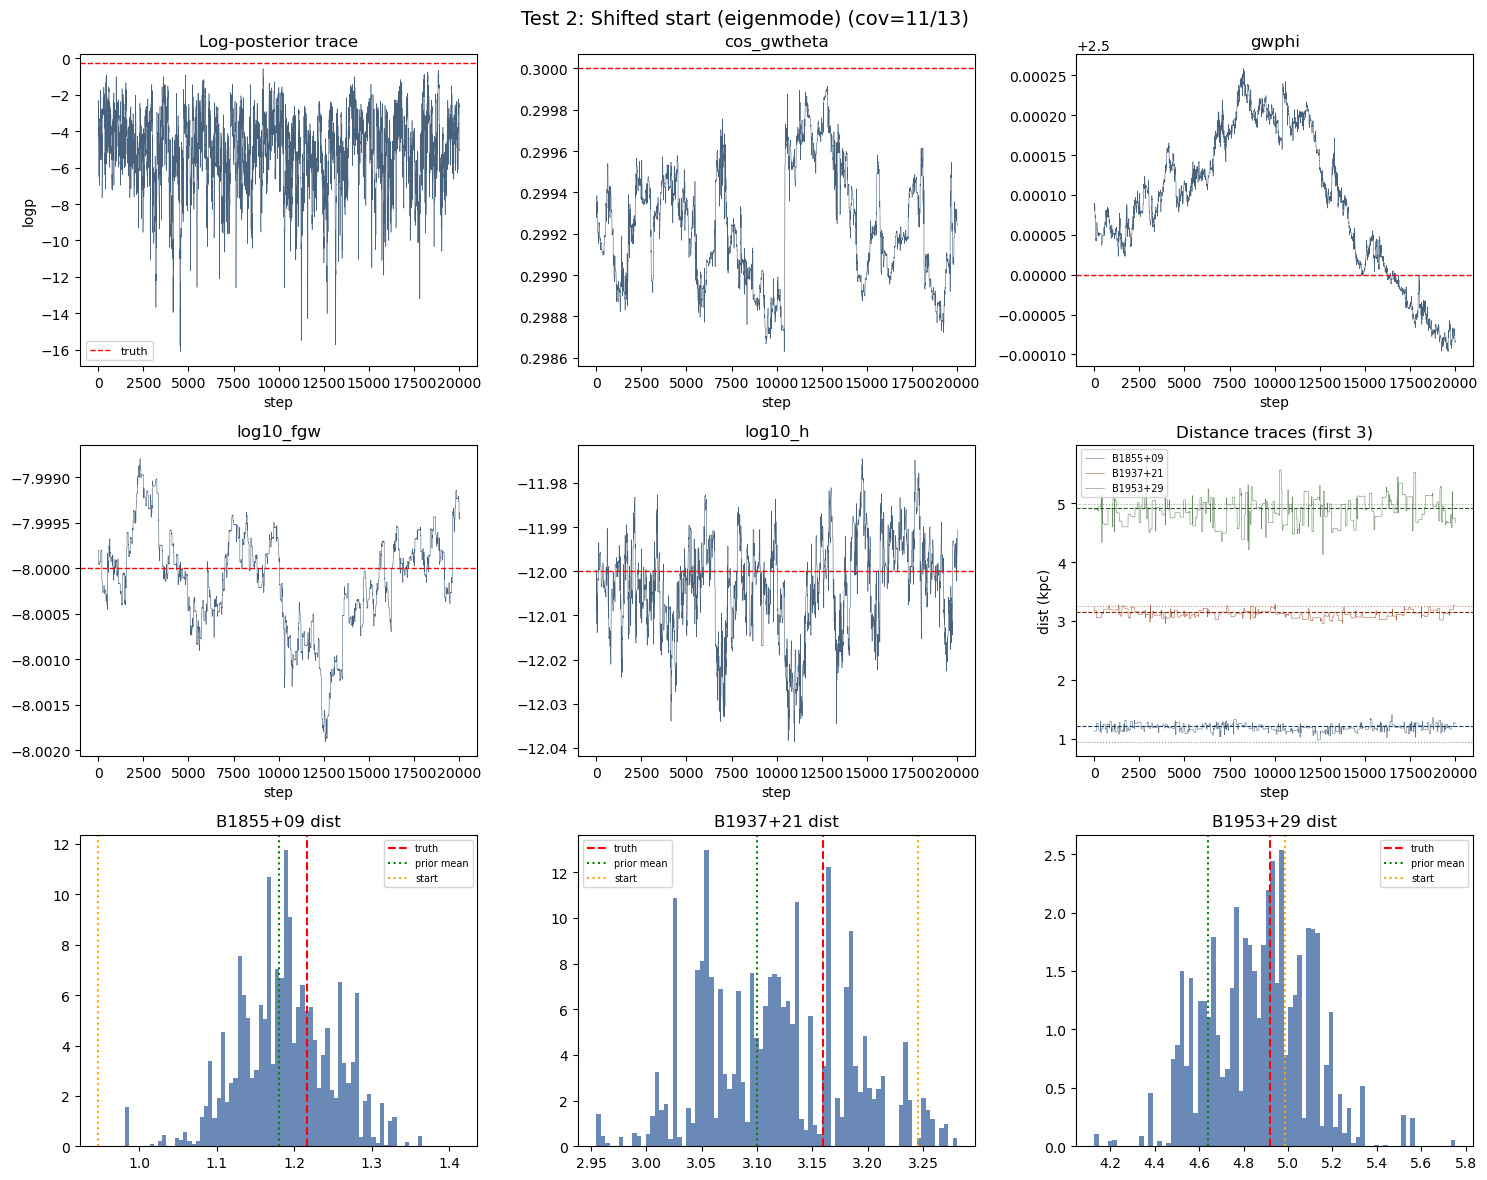

In [8]:
# Create a shifted starting point
rng_shift = np.random.default_rng(123)

x_shifted = p5_truth.copy()
mode_offsets = []

print("Shifting distances to wrong modes (within 2-sigma of prior)...")
for j in range(Npulsars):
    mu_j = float(dist_mu[j])
    sig_j = float(dist_sig[j])
    dL_j = dL_truth[j]
    
    max_modes_up = int((mu_j + 2*sig_j - p5_truth[8+j]) / dL_j)
    max_modes_dn = int((p5_truth[8+j] - max(mu_j - 2*sig_j, dL_j)) / dL_j)
    lo = min(-max_modes_dn, -3)
    hi = max(max_modes_up, 3)
    n_shift = rng_shift.integers(lo, hi+1)
    if n_shift == 0:
        n_shift = rng_shift.choice([-3, 3])
    
    x_shifted[8+j] += n_shift * dL_j
    x_shifted[8+j] = np.clip(x_shifted[8+j], dL_j, mu_j + 2*sig_j)
    mode_offsets.append(n_shift)

# Snap each distance to the nearest actual mode peak
print("Snapping to nearest mode peaks...")
for j in range(Npulsars):
    d_new = snap_to_peak(x_shifted, j, float(dL_truth[j]), n_pts=200)
    x_shifted[8+j] = d_new

lp_shifted = float(logp(jnp.array(x_shifted)))
print(f"\nShifted starting point:")
print(f"  logp = {lp_shifted:.2f}  (truth = {lp_truth:.2f}, delta = {lp_shifted - lp_truth:.2f})")
for j in range(Npulsars):
    err_dL = abs(x_shifted[8+j] - p5_truth[8+j]) / dL_truth[j]
    nsig = (x_shifted[8+j] - float(dist_mu[j])) / float(dist_sig[j])
    print(f"  {disco_psrs[j].name}: err = {err_dL:.0f} dL from truth, "
          f"{nsig:+.2f} sigma from prior")

# Compute Fisher at the shifted starting point (not truth!)
print(f"\nComputing Fisher at shifted start:")
fisher_s = compute_fisher(x_shifted, logp)

# Run sampler
print(f"\nRunning sampler from shifted start...")
dL_shifted = np.array(compute_delta_L(x_shifted[0], x_shifted[1], x_shifted[4]))

chain2, lps2, ar2 = run_sampler(
    logp, x_shifted.copy(), np.random.default_rng(42),
    fisher_dict=fisher_s, dL_arr=dL_shifted, mu_arr=mu_arr, sig_arr=sd_arr,
    n_burn=8000, n_prod=20000, report_every=5000,
    p_cw_eigen=0.50, p_dist_within=0.05,
    p_big_jump=0.20, p_freq_dist=0.10,
    p_cw_joint=0.15)

cov2, ess2 = run_diagnostics(chain2, lps2, ar2, p5_truth, dL_truth,
                              title='Test 2: Shifted start (eigenmode)',
                              show_start=x_shifted)

In [9]:
# Side-by-side comparison
print(f"{'='*70}")
print(f"{'':25s} {'Test 1 (truth)':>18s} {'Test 2 (shifted)':>18s}")
print(f"{'='*70}")
print(f"{'Coverage':25s} {cov1:>13d}/13   {cov2:>13d}/13")
print(f"{'ESS min':25s} {min(ess1.values()):>16.0f}   {min(ess2.values()):>16.0f}")
print(f"{'ESS max':25s} {max(ess1.values()):>16.0f}   {max(ess2.values()):>16.0f}")
print(f"{'CW Eigen AR':25s} {ar1['cw_eigen']:>16.4f}   {ar2['cw_eigen']:>16.4f}")
print(f"{'CW Joint AR':25s} {ar1['cw_joint']:>16.4f}   {ar2['cw_joint']:>16.4f}")
print(f"{'Freq-dist AR':25s} {ar1['freq_dist']:>16.4f}   {ar2['freq_dist']:>16.4f}")
print(f"{'Dist within AR':25s} {ar1['dist_within']:>16.4f}   {ar2['dist_within']:>16.4f}")
print(f"{'Big jump AR':25s} {ar1['big_jump']:>16.4f}   {ar2['big_jump']:>16.4f}")
print(f"{'='*70}")

print(f"\nPer-pulsar distance errors (dL from truth):")
print(f"  {'Pulsar':13s} {'Test 1':>10s} {'Test 2':>10s}")
for j in range(Npulsars):
    med1 = np.median(chain1[:, 8+j])
    med2 = np.median(chain2[:, 8+j])
    err1 = abs(med1 - p5_truth[8+j]) / dL_truth[j]
    err2 = abs(med2 - p5_truth[8+j]) / dL_truth[j]
    print(f"  {disco_psrs[j].name:13s} {err1:>10.1f} {err2:>10.1f}")

                              Test 1 (truth)   Test 2 (shifted)
Coverage                             10/13              11/13
ESS min                                 17                 21
ESS max                                259                377
CW Eigen AR                         0.3668             0.3608
CW Joint AR                         0.1304             0.1084
Freq-dist AR                        0.4133             0.4117
Dist within AR                      0.7171             0.7210
Big jump AR                         0.4125             0.3988

Per-pulsar distance errors (dL from truth):
  Pulsar            Test 1     Test 2
  B1855+09            50.6       48.6
  B1937+21            97.5       76.6
  B1953+29           169.0       55.3
  J0023+0923          52.5       50.0
  J0030+0451           2.4        2.9
